## Independent Runs Analysis

This notebook analyses the results of boundary optimization across independent
runs (different random seeds) and folds.  The main questions are:

1. **Reproducibility of the optimized insulation score** – do different runs
   converge to similar `insul_score_diff` values for the same region?
2. **Reproducibility of CTCF placement** – do runs insert CTCFs at the same
   positions and orientations (Jaccard index)?
3. **Pre-optimization CTCF-likeness** – were the sequences at positions where
   CTCFs appeared already CTCF-like before optimization?

## 1. Imports and configuration

In [1]:
import os
import sys
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from pyfaidx import Fasta
from scipy.stats import pearsonr

sys.path.insert(0, os.path.abspath("/home1/smaruj/ledidi_akita/"))

from utils.df_utils import load_indep_runs_results
from utils.fimo_utils import read_meme_pwm_as_numpy, estimate_background_probs

from helper import (
    REGION_COLS, CENTER_BIN, BIN_SIZE, N_RUNS,
    compute_jaccard,
    plot_jaccard_matrices,
    plot_ctcf_orientations,
    plot_pairwise_runs,
    collect_ctcf_sites,
    count_ctcf_reproducibility,
    score_ctcf_sites,
    plot_score_vs_fraction,
    decode_ohe,
)

In [2]:
# ── paths ─────────────────────────────────────────────────────────────────────
INDEP_RUNS_DIR = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundaries/indep_runs_lambda_125.0")
SCORES_TSV     = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundaries/all_folds_positive_motif_score_calculated.tsv")
SEQ_DIR        = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/analysis/flat_regions/mouse_sequences")
GENOME_FASTA   = "/project2/fudenber_735/genomes/mm10/mm10.fa"
CTCF_MEME      = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"
PLOTS_DIR      = Path("./../plots/")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load optimization results

Each row represents one optimization run for one genomic region in one fold.   
`insul_score_diff` is the change in predicted insulation score (negative = stronger boundary).   
`optimization_success` flags runs where the boundary was strengthened.   

In [3]:
df_runs = load_indep_runs_results(INDEP_RUNS_DIR)

df_runs["insul_score_diff"]     = df_runs["insul_score_edited"] - df_runs["insul_score_orig"]
df_runs["optimization_success"] = df_runs["insul_score_diff"] < 0

print(f"Loaded {len(df_runs)} rows ({df_runs['run'].nunique()} runs x {df_runs['fold'].nunique()} folds)")
print(f"Overall success rate: {df_runs['optimization_success'].mean():.1%}")

Loaded 1740 rows (10 runs x 4 folds)
Overall success rate: 89.4%


## 3. Reproducibility of optimized insulation scores

 We first check whether independent runs converge to similar `insul_score_diff`
 values for the same region.  The full pairwise grid covers all 45 run pairs;
 the single panel below focuses on runs 0 vs 1 for use in figures.

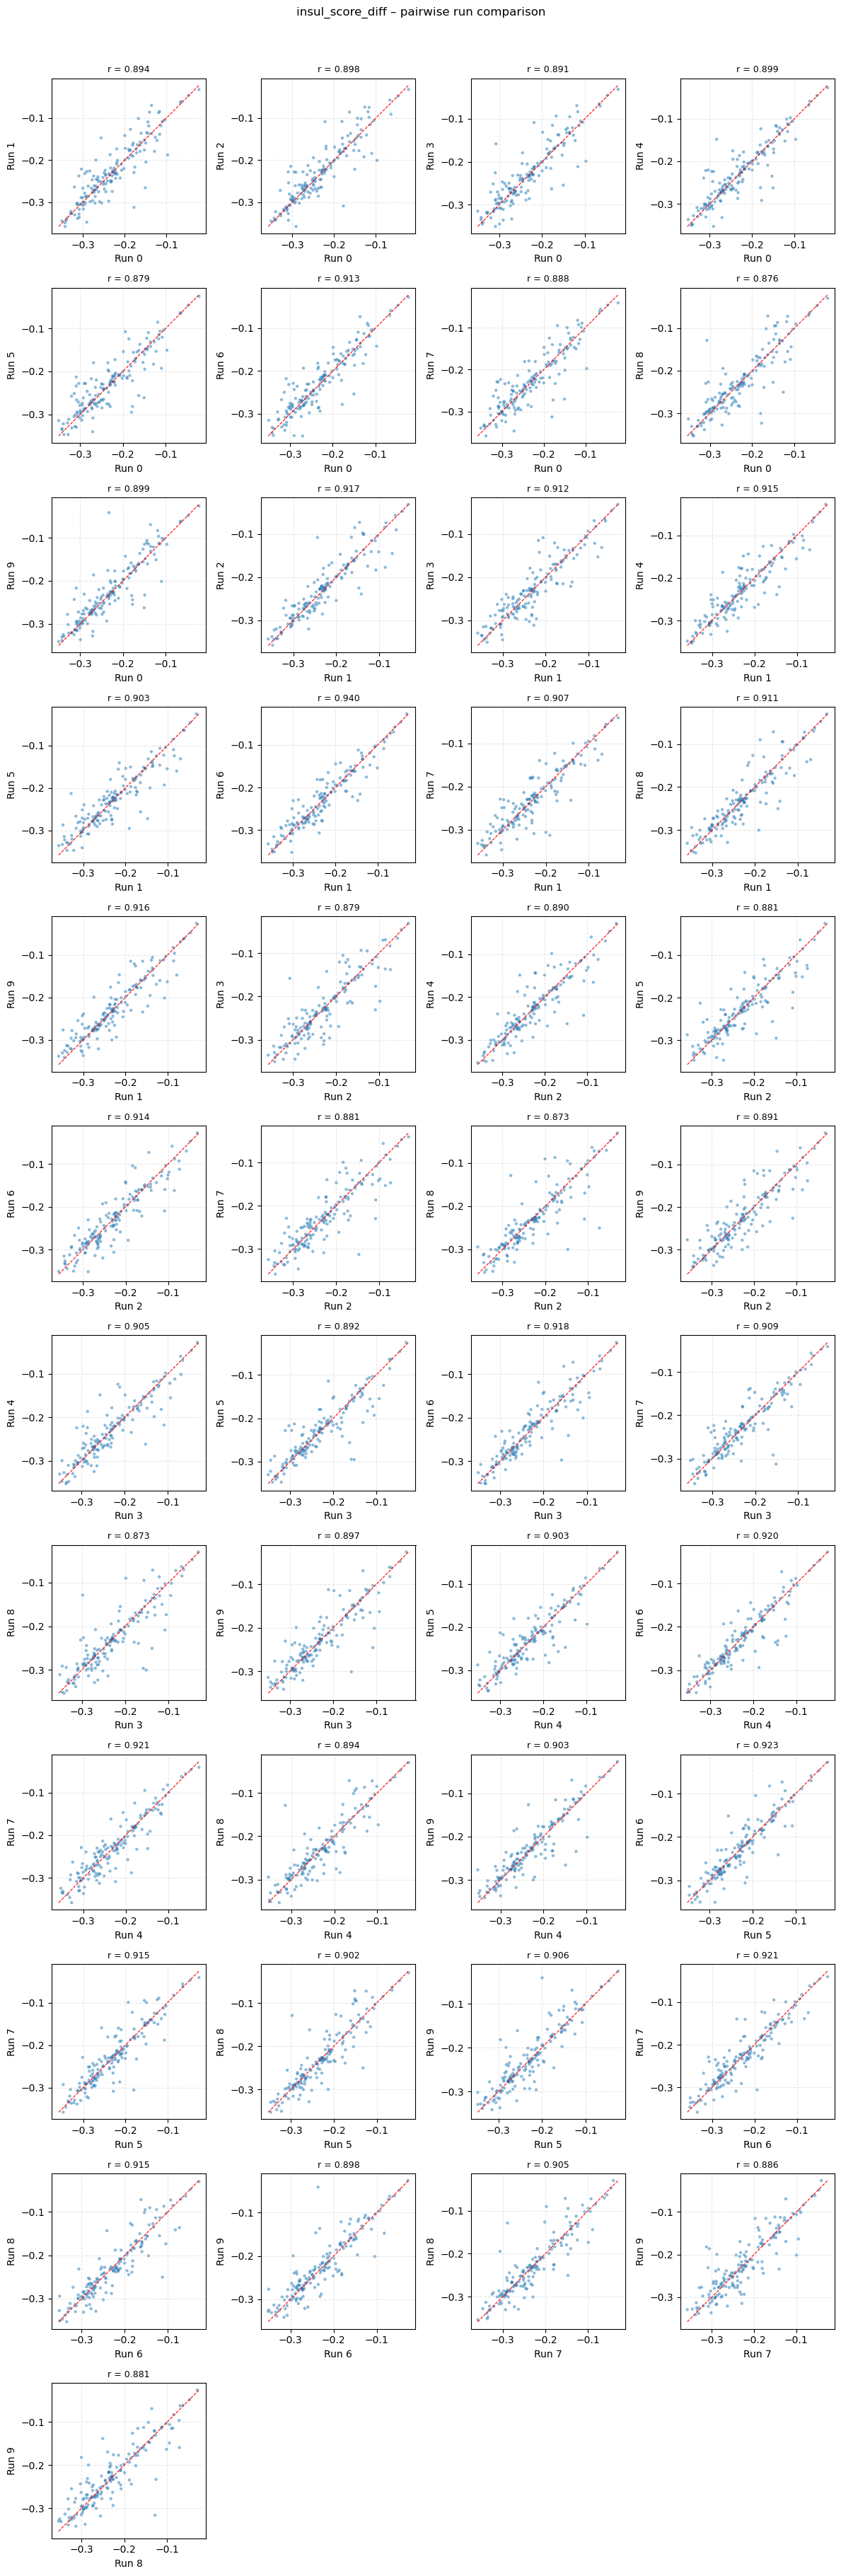

In [4]:
# Full pairwise grid (all 45 pairs)
fig, axes = plot_pairwise_runs(
    df_runs,
    # savepath=PLOTS_DIR / "pairwise_runs_insul_score_diff.svg",
)
plt.show()

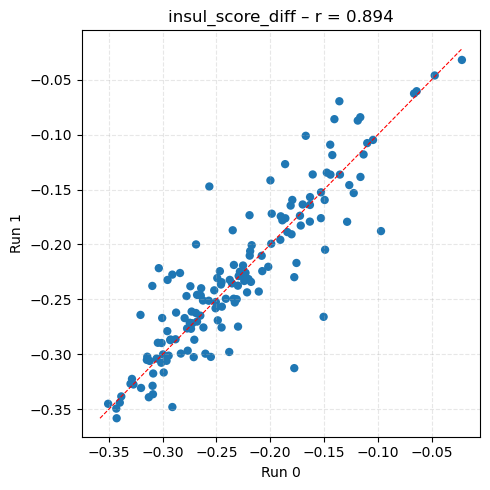

In [5]:
# Single panel: run 0 vs run 1
pivot = (
    df_runs[df_runs["optimization_success"] & df_runs["run"].isin([0, 1])]
    .pivot_table(index=REGION_COLS, columns="run", values="insul_score_diff")
    .dropna()
)

r, _ = pearsonr(pivot[0], pivot[1])
lim = [min(pivot[0].min(), pivot[1].min()), max(pivot[0].max(), pivot[1].max())]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pivot[0], pivot[1], edgecolors="none")
ax.plot(lim, lim, "r--", linewidth=0.8)
ax.set_xlabel("Run 0")
ax.set_ylabel("Run 1")
ax.set_title(f"insul_score_diff – r = {r:.3f}")
ax.grid(alpha=0.3, linestyle="--")
fig.tight_layout()
# fig.savefig(PLOTS_DIR / "run0_vs_run1_insul_score_diff.svg", format="svg", bbox_inches="tight")
plt.show()

## 4. Reproducibility of CTCF placement (Jaccard index)

 For each region we compute the pairwise Jaccard index between runs based on
 the set of CTCF sites (position + orientation) placed during optimization.
 A Jaccard index of 1 means two runs placed identical sites; 0 means no overlap.

 We restrict to regions where all `N_RUNS` runs succeeded, then sample 8
 regions at random for visual inspection.

In [6]:
jaccard_df, avg_jaccard_df = compute_jaccard(df_runs)

successful_regions = list(
    df_runs[df_runs["optimization_success"]]
    .groupby(REGION_COLS)
    .filter(lambda g: len(g) == N_RUNS)
    [REGION_COLS]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)
print(f"{len(successful_regions)} regions with all {N_RUNS} runs successful")

137 regions with all 10 runs successful


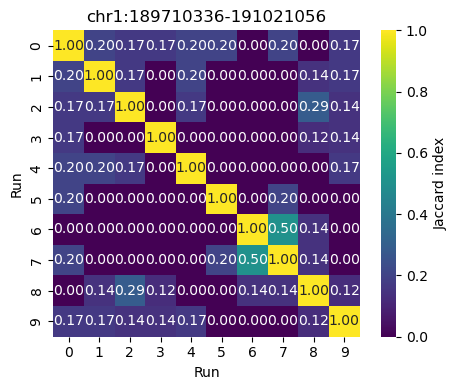

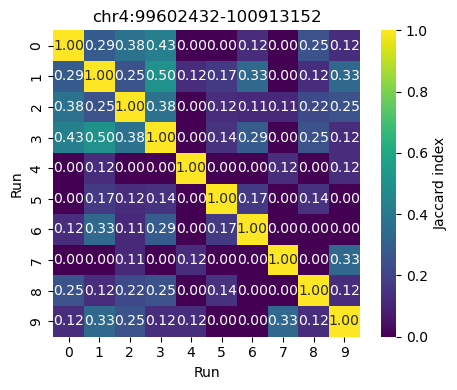

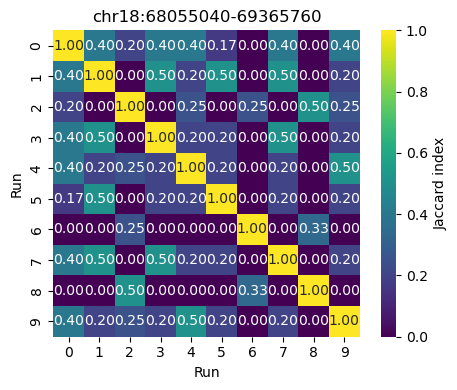

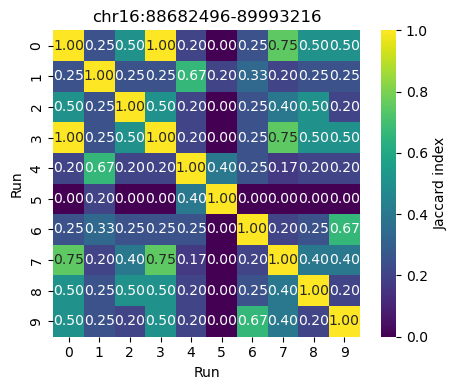

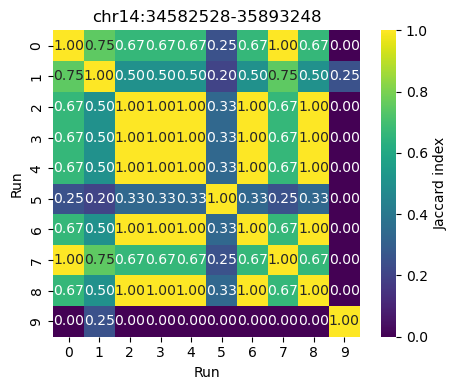

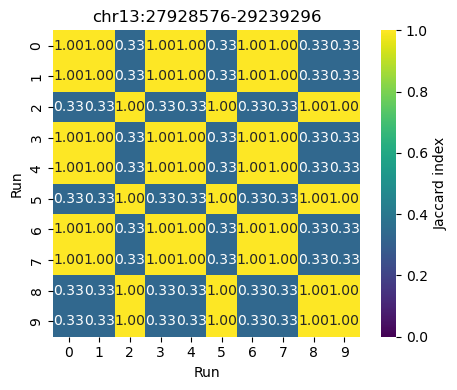

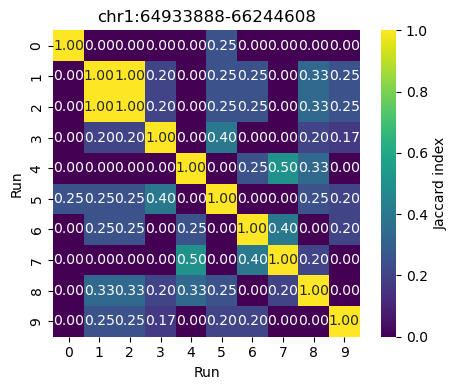

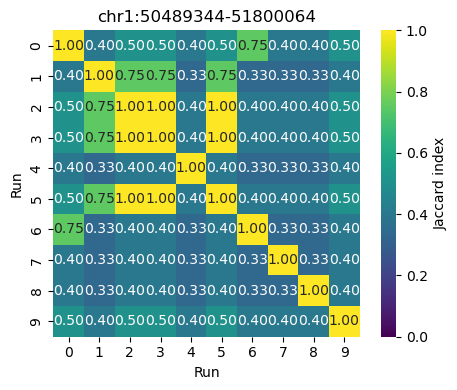

In [7]:
random.seed(42)
sample_regions = random.sample(successful_regions, k=8)
plot_jaccard_matrices(
    sample_regions, jaccard_df,
    # savedir=PLOTS_DIR,
)

### 4.1 Jaccard index vs. pre-existing CTCF motif strength

 We test whether regions with stronger pre-existing CTCF motifs (measured by
 `sum_positive_scores` from FIMO scanning before optimization) show higher
 reproducibility of CTCF placement across runs.

In [8]:
df_scores = pd.read_csv(SCORES_TSV, sep="\t")

scatter_df = (
    avg_jaccard_df
    .merge(df_scores[REGION_COLS + ["sum_positive_scores"]], on=REGION_COLS, how="inner")
    .dropna()
)

Pearson r = 0.225,  p = 3.14e-03


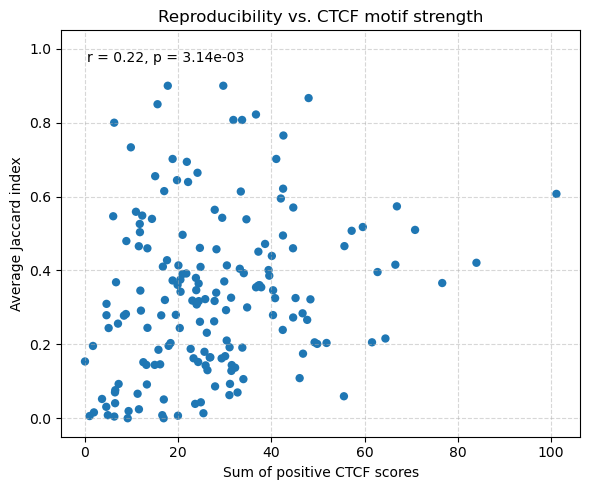

In [9]:
r, pval = pearsonr(scatter_df["sum_positive_scores"], scatter_df["avg_jaccard"])
print(f"Pearson r = {r:.3f},  p = {pval:.2e}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(scatter_df["sum_positive_scores"], scatter_df["avg_jaccard"], edgecolors="none")
ax.set_xlabel("Sum of positive CTCF scores")
ax.set_ylabel("Average Jaccard index")
ax.set_title("Reproducibility vs. CTCF motif strength")
ax.set_ylim(-0.05, 1.05)
ax.text(0.05, 0.95, f"r = {r:.2f}, p = {pval:.2e}", transform=ax.transAxes, va="top")
ax.grid(alpha=0.5, linestyle="--")
fig.tight_layout()
# fig.savefig(PLOTS_DIR / "jaccard_vs_sum_positive_scores.svg", format="svg", bbox_inches="tight")
plt.show()

## 5. Pre-optimization CTCF-likeness

 For each unique CTCF site placed during optimization, we retrieve the
 corresponding subsequence from the pre-optimization one-hot encoded sequence
 and score it against the CTCF PWM (MA0139.1).

 The question is: were positions where CTCFs consistently appeared across runs
 already more CTCF-like before optimization?

In [10]:
genome   = Fasta(GENOME_FASTA)
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_MEME)
bg_probs = estimate_background_probs(df_runs, genome)
print(f"CTCF PWM shape: {pwm_CTCF.shape}  (expected (19, 4))")
print("Background probabilities:", {k: round(v, 4) for k, v in bg_probs.items()})

CTCF PWM shape: (19, 4)  (expected (19, 4))
Background probabilities: {'A': 0.2899, 'C': 0.2101, 'G': 0.2099, 'T': 0.2901}


In [11]:
ctcf_df     = collect_ctcf_sites(df_runs)
ctcf_counts = count_ctcf_reproducibility(ctcf_df, n_runs=N_RUNS)
ctcf_counts = score_ctcf_sites(ctcf_df, df_runs, ctcf_counts, SEQ_DIR, pwm_CTCF, bg_probs)

100%|██████████| 1942/1942 [00:00<00:00, 2122.40it/s]


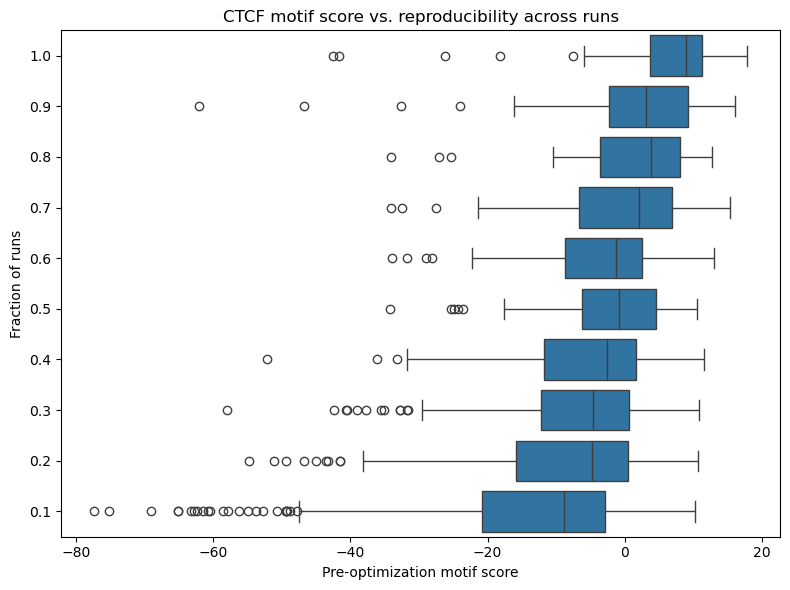

In [12]:
plot_score_vs_fraction(
    ctcf_counts,
    figsize=(8, 6),
    # savepath=PLOTS_DIR / "pre-opt_motif_score_vs_fraction.svg",
)
plt.show()

## 6. CTCF orientation plot for a single region

 Visual inspection of where and in which orientation CTCFs were placed across
 all independent runs for a selected region. Runs are clustered by spatial
 similarity of their CTCF patterns.

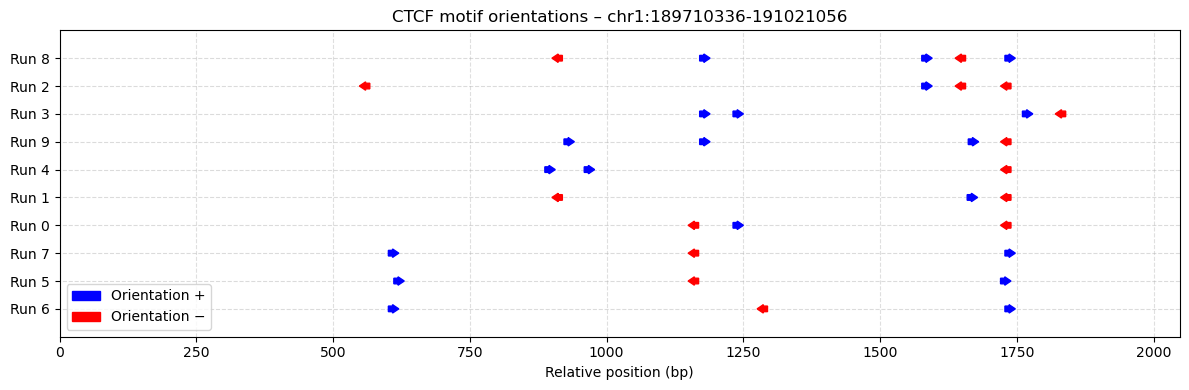

In [13]:
region = ("chr1", 189710336, 191021056)

fig, ax = plot_ctcf_orientations(
    df_runs,
    region,
    # savepath=PLOTS_DIR / "ctcf_indep_runs_lambda_125.0.svg",
)
plt.show()

### 6.1 Comparison: default lambda (λ = 0.01)

 The same CTCF orientation plot for the same region, but using runs optimized
 with the default lambda. This allows a direct visual comparison of how the
 CTCF penalty strength affects placement reproducibility.

In [14]:
INDEP_RUNS_DIR_DEFAULT = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundaries/indep_runs_lambda_0.01")

df_runs_default_lambda = load_indep_runs_results(INDEP_RUNS_DIR_DEFAULT)
df_runs_default_lambda["insul_score_diff"]     = df_runs_default_lambda["insul_score_edited"] - df_runs_default_lambda["insul_score_orig"]
df_runs_default_lambda["optimization_success"] = df_runs_default_lambda["insul_score_diff"] < 0

print(f"Loaded {len(df_runs_default_lambda)} rows ({df_runs_default_lambda['run'].nunique()} runs x {df_runs_default_lambda['fold'].nunique()} folds)")
print(f"Overall success rate: {df_runs_default_lambda['optimization_success'].mean():.1%}")

Loaded 1740 rows (10 runs x 4 folds)
Overall success rate: 100.0%


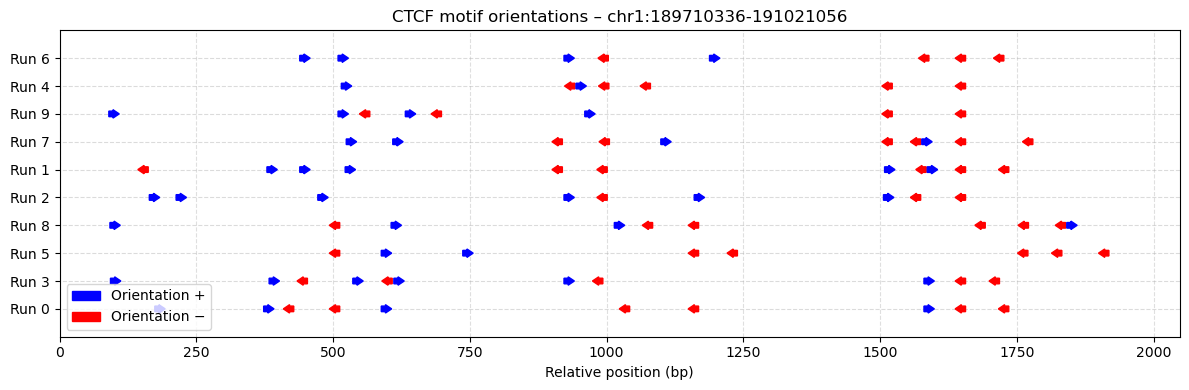

In [15]:
fig, ax = plot_ctcf_orientations(
    df_runs_default_lambda,
    region,
    # savepath=PLOTS_DIR / "ctcf_indep_runs_lambda_0.01.svg",
)
plt.show()

## 7. Manual inspection of pre-optimization sequences at CTCF sites

 We load the pre-optimization one-hot encoded sequence for a selected region
 and decode specific subsequences to verify what the sequence looked like at
 positions where CTCFs were inserted.

In [16]:
chrom, start, end = region
fold = 1

ohe_path = (
    f"{SEQ_DIR}/fold{fold}/{chrom}_{start}_{end}_X.pt"
)
ohe = torch.load(ohe_path, map_location="cpu")           # (1, 4, 1310720)
ohe_slice = ohe[0, :, CENTER_BIN * BIN_SIZE : (CENTER_BIN + 1) * BIN_SIZE].numpy()  # (4, 2048)

In [17]:
# Print all CTCF positions found in this region across runs
region_df = df_runs[
    (df_runs["chrom"] == chrom) &
    (df_runs["centered_start"] == start) &
    (df_runs["centered_end"] == end)
]
for _, row in region_df.iterrows():
    print(f"run {row['run']}: {row['positions']}")

run 0: [(1168, 1187), (1231, 1250), (1739, 1758)]
run 1: [(919, 938), (1659, 1678), (1739, 1758)]
run 2: [(567, 586), (1576, 1595), (1656, 1675), (1739, 1758)]
run 3: [(1170, 1189), (1231, 1250), (1760, 1779), (1839, 1858)]
run 4: [(887, 906), (959, 978), (1739, 1758)]
run 5: [(611, 630), (1168, 1187), (1720, 1739)]
run 6: [(601, 620), (1294, 1313), (1728, 1747)]
run 7: [(601, 620), (1168, 1187), (1728, 1747)]
run 8: [(919, 938), (1170, 1189), (1576, 1595), (1656, 1675), (1728, 1747)]
run 9: [(922, 941), (1170, 1189), (1661, 1680), (1739, 1758)]


In [18]:
# Decode specific sites — adjust rel_start / rel_end to the site of interest
for (rel_start, rel_end, rev_comp, label) in [
    (1168, 1187, True,  "site A (rev comp)"),
    (1739, 1758, True,  "site B (rev comp)"),
    (1170, 1189, False, "site C (forward)"),
]:
    site_ohe = ohe_slice[:, rel_start:rel_end]
    print(f"{label:25s}  {decode_ohe(site_ohe, rev_comp=rev_comp)}")

site A (rev comp)          CTTACACCTTGGGGCATCA
site B (rev comp)          TGGCCAGGCAGCAGGGCTA
site C (forward)           ATGCCCCAAGGTGTAAGGA
